<a href="https://colab.research.google.com/github/beniamine3155/Data_Science_Projects/blob/main/Cat_Dog_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Extracting Dataset Using Kaggle API

#### https://www.kaggle.com/c/dogs-vs-cats/data

In [8]:
!pip install kaggle

In [9]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
!kaggle competitions download -c dogs-vs-cats

100% 809M/812M [00:10<00:00, 194MB/s]
100% 812M/812M [00:10<00:00, 80.8MB/s]


In [11]:
!ls

dogs-vs-cats.zip  kaggle.json  sample_data


In [12]:
# extracting the compress dataset
from zipfile import ZipFile

dataset = "/content/dogs-vs-cats.zip"

with ZipFile(dataset, 'r') as z:
  z.extractall()
  print("dataset extracted")

dataset extracted


In [13]:
# extracting the train dataset
from zipfile import ZipFile

dataset = '/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [14]:
import os
# counting the number of files in train folder
path, dirs, files = next(os.walk('/content/train'))
file_count = len(files)
print(file_count)

25000


In [15]:
# pringting the name of images
file_names = os.listdir('/content/train/')
print(file_names)

['cat.3530.jpg', 'cat.11705.jpg', 'dog.1044.jpg', 'dog.63.jpg', 'cat.7682.jpg', 'dog.1494.jpg', 'dog.5111.jpg', 'dog.5827.jpg', 'cat.10842.jpg', 'dog.5565.jpg', 'cat.3457.jpg', 'cat.4891.jpg', 'cat.1998.jpg', 'dog.3797.jpg', 'cat.6186.jpg', 'cat.1967.jpg', 'dog.1204.jpg', 'cat.7932.jpg', 'cat.8886.jpg', 'dog.3156.jpg', 'cat.11339.jpg', 'cat.11765.jpg', 'dog.9828.jpg', 'cat.3529.jpg', 'dog.9487.jpg', 'dog.3969.jpg', 'dog.442.jpg', 'cat.4993.jpg', 'cat.1133.jpg', 'dog.2838.jpg', 'cat.3798.jpg', 'cat.8952.jpg', 'cat.11937.jpg', 'cat.1089.jpg', 'dog.9577.jpg', 'dog.2910.jpg', 'cat.11603.jpg', 'dog.8879.jpg', 'cat.337.jpg', 'cat.11797.jpg', 'cat.10112.jpg', 'dog.10422.jpg', 'dog.9756.jpg', 'cat.10776.jpg', 'cat.449.jpg', 'cat.5373.jpg', 'cat.2040.jpg', 'cat.2187.jpg', 'dog.2100.jpg', 'cat.8448.jpg', 'cat.177.jpg', 'dog.3807.jpg', 'dog.1565.jpg', 'dog.5712.jpg', 'dog.9456.jpg', 'dog.3758.jpg', 'cat.9166.jpg', 'dog.11888.jpg', 'dog.10938.jpg', 'dog.4603.jpg', 'cat.6705.jpg', 'dog.4299.jpg', '

### Importing the libraries

In [16]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

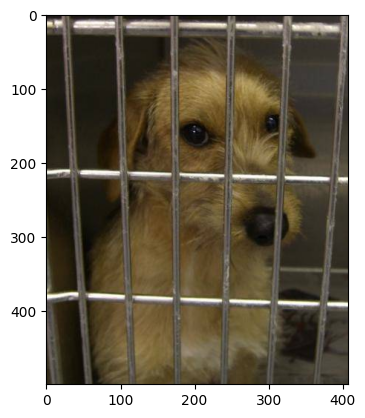

In [24]:
# Display the image of Dog
img = mpimg.imread('/content/train/dog.8492.jpg')
imgplt = plt.imshow(img)
plt.show()

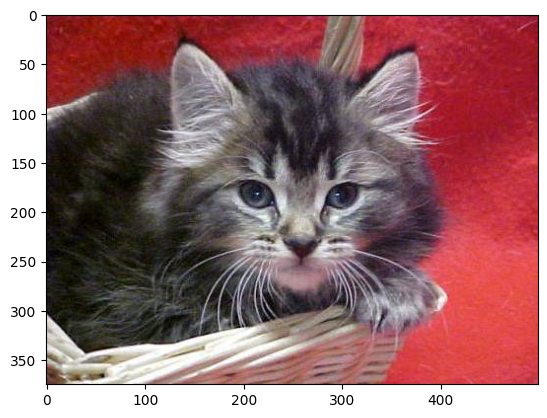

In [22]:
# Display the image of Cat
img = mpimg.imread('/content/train/cat.4468.jpg')
imgplt = plt.imshow(img)
plt.show()

In [25]:
file_names = os.listdir('/content/train/')

for i in range(5):

  name = file_names[i]
  print(name[0:3])

cat
cat
dog
dog
cat


In [26]:
file_names = os.listdir('/content/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count += 1

  else:
    cat_count += 1

print('Number of dog images =', dog_count)
print('Number of cat images =', cat_count)

Number of dog images = 12500
Number of cat images = 12500


### Resizing all the images

In [34]:
#creating a directory for resized images
os.mkdir('/content/image_resized')

In [35]:
original_folder = '/content/train/'
resized_folder = '/content/image_resized/'

for i in range(2000):

  filename = os.listdir(original_folder)[i]
  img_path = original_folder+filename

  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  newImgPath = resized_folder+filename
  img.save(newImgPath)

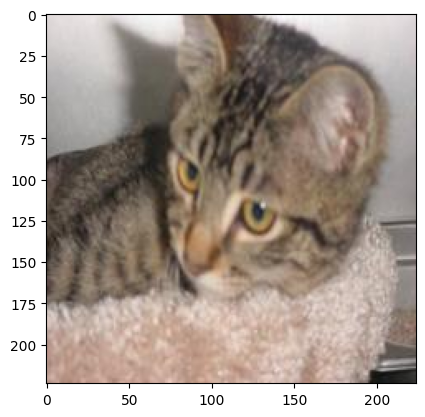

In [37]:
# display resized cat image
img = mpimg.imread('/content/image_resized/cat.10031.jpg')
imgplt = plt.imshow(img)
plt.show()

### Creating labels for resizing images
Cat - 0
Dog - 1

In [38]:
# creaing a for loop to assign labels
filenames = os.listdir('/content/image_resized/')


labels = []

for i in range(2000):

  file_name = filenames[i]
  label = file_name[0:3]

  if label == 'dog':
    labels.append(1)

  else:
    labels.append(0)

In [39]:
print(filenames[0:5])
print(len(filenames))

['cat.3530.jpg', 'cat.11705.jpg', 'dog.1044.jpg', 'dog.63.jpg', 'cat.7682.jpg']
2000


In [40]:
print(labels[0:5])
print(len(labels))

[0, 0, 1, 1, 0]
2000


In [41]:
# counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[1022  978]


### Converting all the resized images to numpy arrays

In [42]:
import cv2
import glob

In [43]:
image_directory = '/content/image_resized/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [44]:
print(dog_cat_images)

[[[[141 170 184]
   [139 168 182]
   [135 166 181]
   ...
   [110 114 108]
   [188 182 175]
   [233 222 214]]

  [[141 170 184]
   [139 168 182]
   [135 166 181]
   ...
   [ 95  99  93]
   [180 174 167]
   [249 238 230]]

  [[140 169 183]
   [138 167 181]
   [135 166 181]
   ...
   [ 96 100  94]
   [184 179 170]
   [255 249 239]]

  ...

  [[151 172 194]
   [155 176 198]
   [157 178 200]
   ...
   [181 197 214]
   [185 201 218]
   [182 198 214]]

  [[154 175 196]
   [160 181 202]
   [164 185 206]
   ...
   [185 200 216]
   [186 201 217]
   [181 197 210]]

  [[156 177 198]
   [162 183 204]
   [169 190 211]
   ...
   [185 200 216]
   [183 199 212]
   [174 190 203]]]


 [[[108 100 101]
   [108 100 101]
   [108 100 101]
   ...
   [145 138 175]
   [158 147 185]
   [169 159 195]]

  [[108 100 101]
   [106 100 101]
   [108 100 101]
   ...
   [146 139 176]
   [157 149 186]
   [169 162 197]]

  [[105  99 100]
   [104  99 100]
   [105  99 100]
   ...
   [148 141 178]
   [158 151 188]
   [170 164

In [45]:
type(dog_cat_images)

numpy.ndarray

In [46]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [47]:
X = dog_cat_images
Y = np.asarray(labels)